--- Task 1: Pandas Exploration ---
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of data: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:

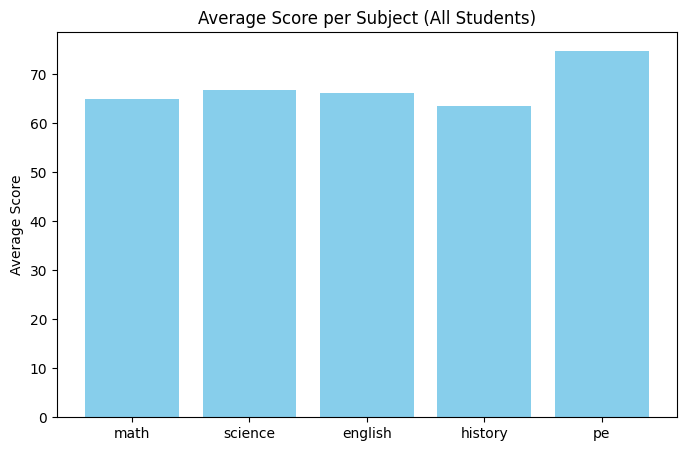

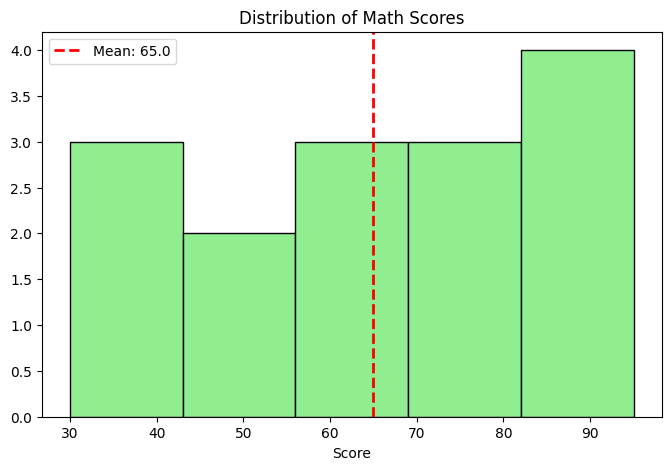

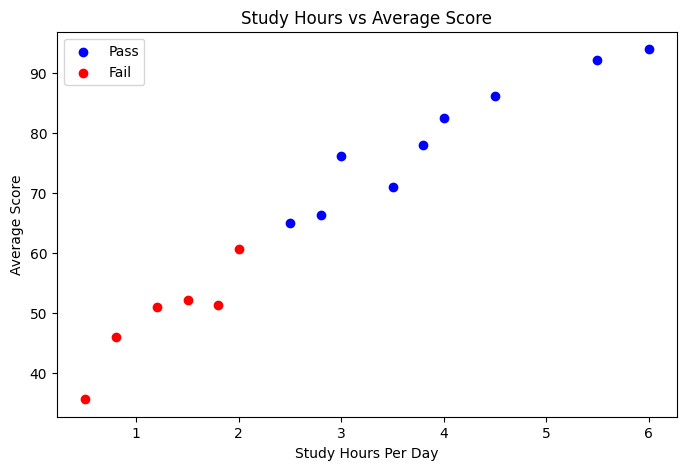

/tmp/ipykernel_6068/2523462648.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


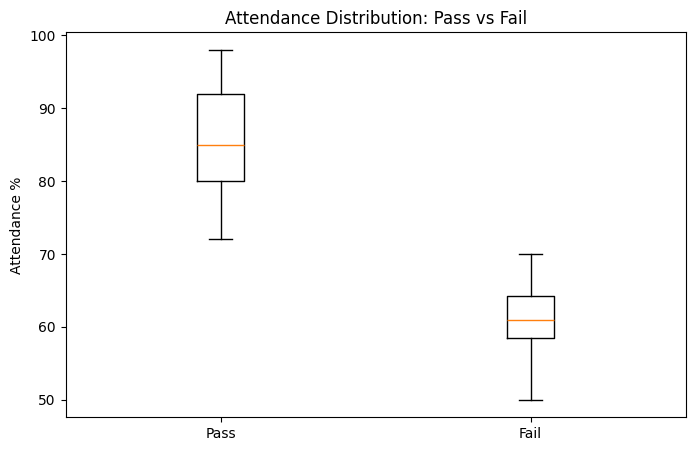

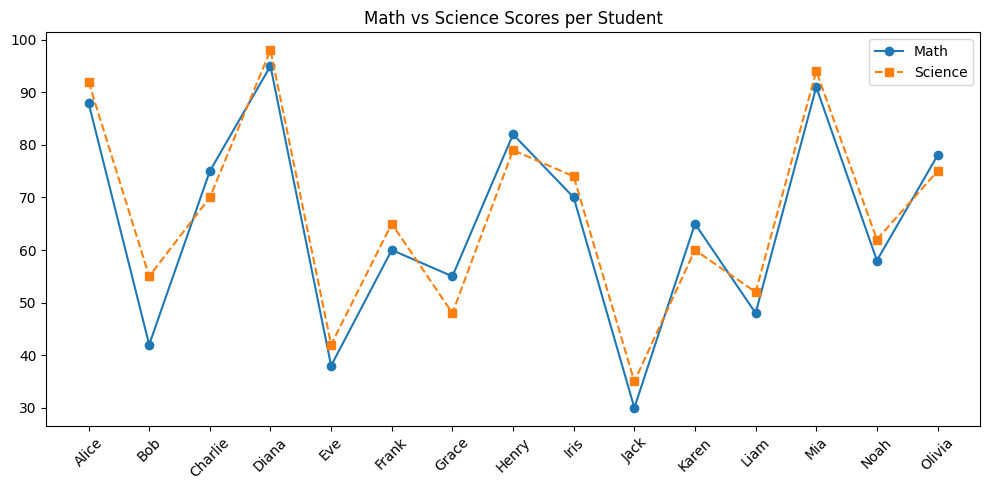


--- Task 3: Seaborn Visualizations ---


/tmp/ipykernel_6068/2523462648.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', palette='muted')
/tmp/ipykernel_6068/2523462648.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', palette='pastel')


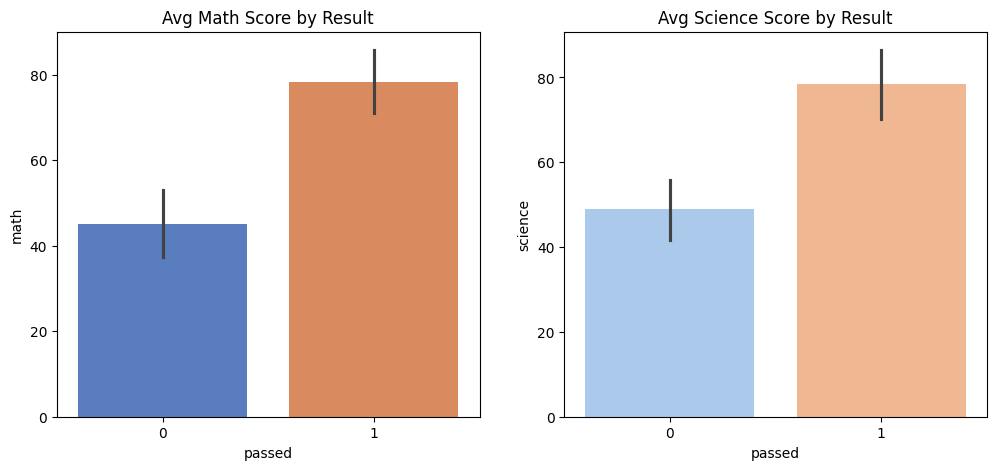

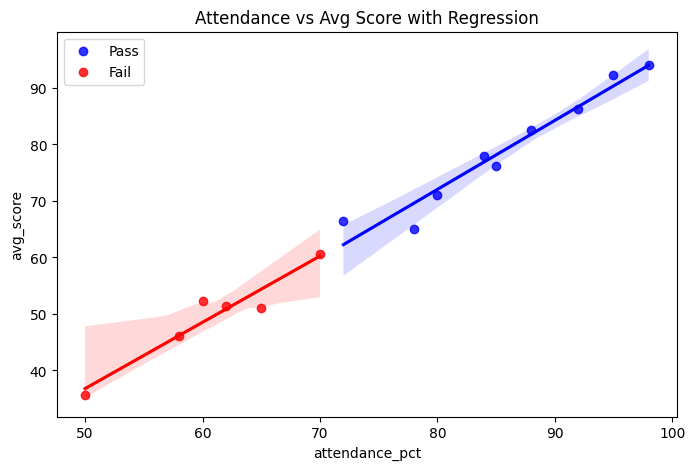


--- Task 4: Machine Learning Pipeline ---
Training Accuracy: 100.00%
Test Accuracy: 100.00%

Individual Test Results:
Jack       | Actual: 0 | Predicted: 0 | ✅
Liam       | Actual: 0 | Predicted: 0 | ✅
Alice      | Actual: 1 | Predicted: 1 | ✅

Feature Importance (Coefficients):
               Feature  Importance
2              english    0.812513
5       attendance_pct    0.521876
6  study_hours_per_day    0.484433
4                   pe    0.474974
0                 math    0.437944
1              science    0.323010
3              history    0.262929


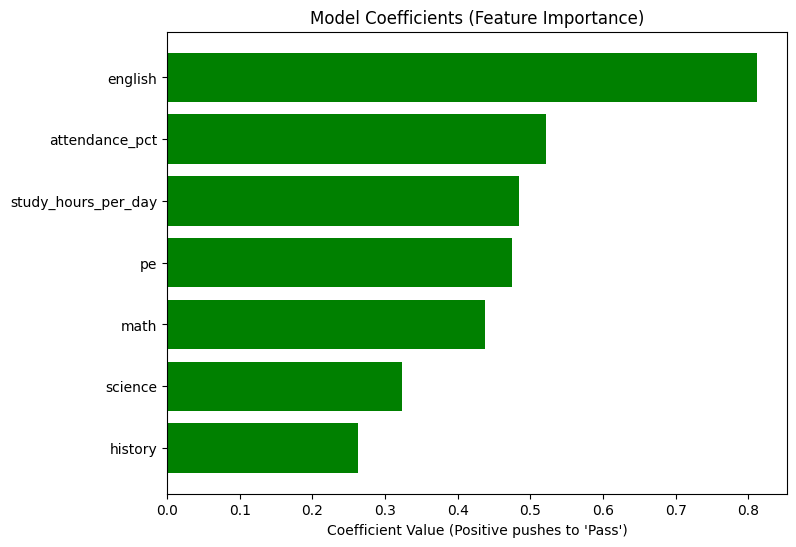


--- New Student Prediction ---
Predicted Result: Pass
Probability (Fail/Pass): [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import io

# ==========================================
# Data Setup
# ==========================================

# I am creating the CSV file programmatically so the script is self-contained
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open("students.csv", "w") as f:
    f.write(csv_data)

# ==========================================
# Task 1: Data Exploration with Pandas
# ==========================================
print("--- Task 1: Pandas Exploration ---")
df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

print(f"\nShape of data: {df.shape}")
print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

print("\nPass vs Fail Count:")
print(df['passed'].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores - Passing Students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores - Failing Students:")
print(df[df['passed'] == 0][subject_cols].mean())

# Finding the top student
df['avg_score'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_score'].idxmax()]
print(f"\nTop Student: {top_student['name']} with Average: {top_student['avg_score']:.2f}")


# ==========================================
# Task 2: Data Visualization with Matplotlib
# ==========================================
print("\n--- Task 2: Matplotlib Visualizations ---")

# 1. Bar Chart - Average score per subject
plt.figure(figsize=(8, 5))
subject_means = df[subject_cols].mean()
plt.bar(subject_means.index, subject_means.values, color='skyblue')
plt.title("Average Score per Subject (All Students)")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram - Math scores
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

# 3. Scatter Plot - Study Hours vs Avg Score
plt.figure(figsize=(8, 5))
pass_group = df[df['passed'] == 1]
fail_group = df[df['passed'] == 0]
plt.scatter(pass_group['study_hours_per_day'], pass_group['avg_score'], color='blue', label='Pass')
plt.scatter(fail_group['study_hours_per_day'], fail_group['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box Plot - Attendance
plt.figure(figsize=(8, 5))
pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_boxplot.png")
plt.show()

# 5. Line Plot - Math vs Science
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', linestyle='-')
plt.plot(df['name'], df['science'], marker='s', label='Science', linestyle='--')
plt.title("Math vs Science Scores per Student")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


# ==========================================
# Task 3: Data Visualization with Seaborn
# ==========================================
print("\n--- Task 3: Seaborn Visualizations ---")

plt.figure(figsize=(12, 5))

# Subplot 1: Math vs Science split by passed
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', palette='muted')
plt.title("Avg Math Score by Result")

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', palette='pastel')
plt.title("Avg Science Score by Result")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Regression plot
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red')
plt.title("Attendance vs Avg Score with Regression")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# --- Experience Comment ---
# Personally, I found Seaborn much easier for statistical plots like the bar averages
# and regression lines because it handles the grouping and calculation automatically.
# Matplotlib requires more manual setup (like splitting groups yourself), but it
# gives you much more control over the fine details of the layout.


# ==========================================
# Task 4: Machine Learning with scikit-learn
# ==========================================
print("\n--- Task 4: Machine Learning Pipeline ---")

# Step 1: Prepare Data
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

# Splitting 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling - Important so that 'attendance' (0-100) doesn't drown out 'study hours' (0-6)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_acc * 100:.2f}%")

# Step 3: Evaluate
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

# Detailed Test results
print("Individual Test Results:")
test_names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅" if actual == pred else "❌"
    print(f"{name:<10} | Actual: {actual} | Predicted: {pred} | {status}")

# Step 4: Feature Importance
coeffs = model.coef_[0]
feature_importance = pd.DataFrame({'Feature': features, 'Importance': coeffs})
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

print("\nFeature Importance (Coefficients):")
print(feature_importance[['Feature', 'Importance']])

# Importance Plot
plt.figure(figsize=(8, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Importance']]
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.title("Model Coefficients (Feature Importance)")
plt.xlabel("Coefficient Value (Positive pushes to 'Pass')")
plt.gca().invert_yaxis() # Highest importance on top
plt.savefig("plot8_importance.png")
plt.show()

# Step 5: Bonus - Predict for a New Student
# Values: Math 75, Sci 70, Eng 68, Hist 65, PE 80, Att 82, Study 3.2
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"
print(f"\n--- New Student Prediction ---")
print(f"Predicted Result: {result}")
print(f"Probability (Fail/Pass): {probability[0]}")